### Understanding the Dataset:

- It is also known as the "Census Income" dataset.

- The goal is to predict whether an individual’s income exceeds $50K per year based on census data (i.e., personal and employment information)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income'
]




In [2]:
# Load the Adult dataset (training data) - no header in file, so use custom column names , sep by comma and whitespace
df_train = pd.read_csv(r'D:\arc-2025\arc\ai\Uddav-Rajbhandari\supervised_unsupervised_ml\dataset files\adult.data', header=None, names=columns, sep=',\s*', engine='python')

# Load the Adult dataset (test data) - skip the first line (comment), assign column names
df_test = pd.read_csv(r'D:\arc-2025\arc\ai\Uddav-Rajbhandari\supervised_unsupervised_ml\dataset files\adult.test', header=0, names=columns, sep=',\s*', engine='python', skiprows=1)


In [3]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16280 entries, 0 to 16279
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             16280 non-null  int64 
 1   workclass       16280 non-null  object
 2   fnlwgt          16280 non-null  int64 
 3   education       16280 non-null  object
 4   education_num   16280 non-null  int64 
 5   marital_status  16280 non-null  object
 6   occupation      16280 non-null  object
 7   relationship    16280 non-null  object
 8   race            16280 non-null  object
 9   sex             16280 non-null  object
 10  capital_gain    16280 non-null  int64 
 11  capital_loss    16280 non-null  int64 
 12  hours_per_week  16280 non-null  int64 
 13  native_country  16280 non-null  object
 14  income          16280 non-null  object
dtypes: int64(6), object(9)
memory usage: 1.9+ MB


In [4]:
df_train.describe(include='all')

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
count,32561.000000,32561,3.256100e+04,32561,32561.000000,32561,32561,32561,32561,32561,32561.000000,32561.000000,32561.000000,32561,32561
unique,NaN,9,NaN,16,NaN,7,15,6,5,2,NaN,NaN,NaN,42,2
top,NaN,Private,NaN,HS-grad,NaN,Married-civ-spouse,Prof-specialty,Husband,White,Male,NaN,NaN,NaN,United-States,<=50K
freq,NaN,22696,NaN,10501,NaN,14976,4140,13193,27816,21790,NaN,NaN,NaN,29170,24720
mean,38.581647,NaN,1.897784e+05,NaN,10.080679,NaN,NaN,NaN,NaN,NaN,1077.648844,87.303830,40.437456,NaN,NaN
std,13.640433,NaN,1.055500e+05,NaN,2.572720,NaN,NaN,NaN,NaN,NaN,7385.292085,402.960219,12.347429,NaN,NaN
min,17.000000,NaN,1.228500e+04,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,NaN
25%,28.000000,NaN,1.178270e+05,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
50%,37.000000,NaN,1.783560e+05,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
75%,48.000000,NaN,2.370510e+05,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN,NaN


In [5]:
# Count rows where value contains '?' (ignoring leading spaces)
for col in df_train.columns:
    count = df_train[col].astype(str).str.strip().eq('?').sum()
    if count > 0:
        print(f"{col} has {count} '?' values.")


workclass has 1836 '?' values.
occupation has 1843 '?' values.
native_country has 583 '?' values.


In [6]:
# Load the datasets, treat '?' as missing values (NaN)
df_train = pd.read_csv(r'D:\arc-2025\arc\ai\Uddav-Rajbhandari\supervised_unsupervised_ml\dataset files\adult.data', header=None, names=columns, sep=',\s*', engine='python', na_values='?')
df_test = pd.read_csv(r'D:\arc-2025\arc\ai\Uddav-Rajbhandari\supervised_unsupervised_ml\dataset files\adult.test', header=0, names=columns, sep=',\s*', engine='python', skiprows=1, na_values='?')


In [7]:
df_train.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64

In [8]:
df_test.isnull().sum()

age                 0
workclass         963
fnlwgt              0
education           0
education_num       0
marital_status      0
occupation        966
relationship        0
race                0
sex                 0
capital_gain        0
capital_loss        0
hours_per_week      0
native_country    274
income              0
dtype: int64

In [9]:
train_numeric_columns = df_train.select_dtypes(include=[np.number]).columns
train_categorical_columns = df_train.select_dtypes(exclude=[np.number]).columns

test_numeric_columns = df_test.select_dtypes(include=[np.number]).columns
test_categorical_columns = df_test.select_dtypes(exclude=[np.number]).columns

In [10]:
train_categorical_columns.drop('income')  # Exclude target variable from categorical columns
test_categorical_columns.drop('income')  # Exclude target variable from categorical columns


Index(['workclass', 'education', 'marital_status', 'occupation',
       'relationship', 'race', 'sex', 'native_country'],
      dtype='object')

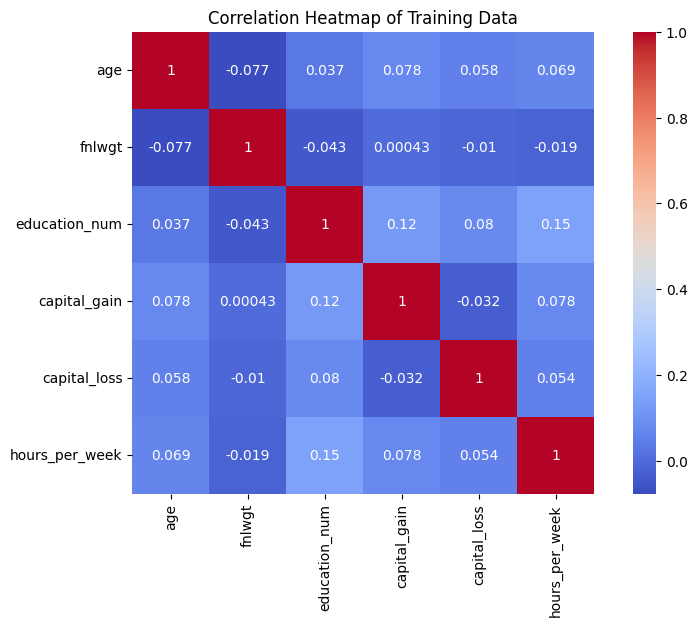

In [11]:
numerical_col = df_train.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(10, 6))
sns.heatmap(df_train[numerical_col].corr(), annot=True, cmap='coolwarm', square=True)
plt.title('Correlation Heatmap of Training Data')
plt.show()


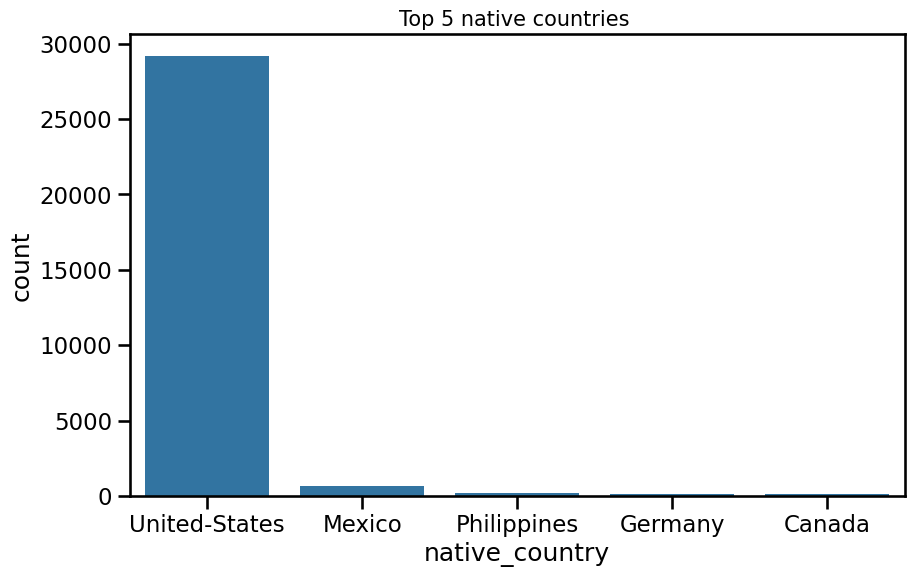

In [12]:
sns.set_context('talk')
fig, ax = plt.subplots(figsize=(10, 6))
c = df_train['native_country'].value_counts()[:5]
ax = sns.barplot(x = c.index, y = c )
ax.set_title('Top 5 native countries ', fontsize=15);

We notice that mayority of the citizens who took part in the census were born in the USA.
the other countries excluding the USA.

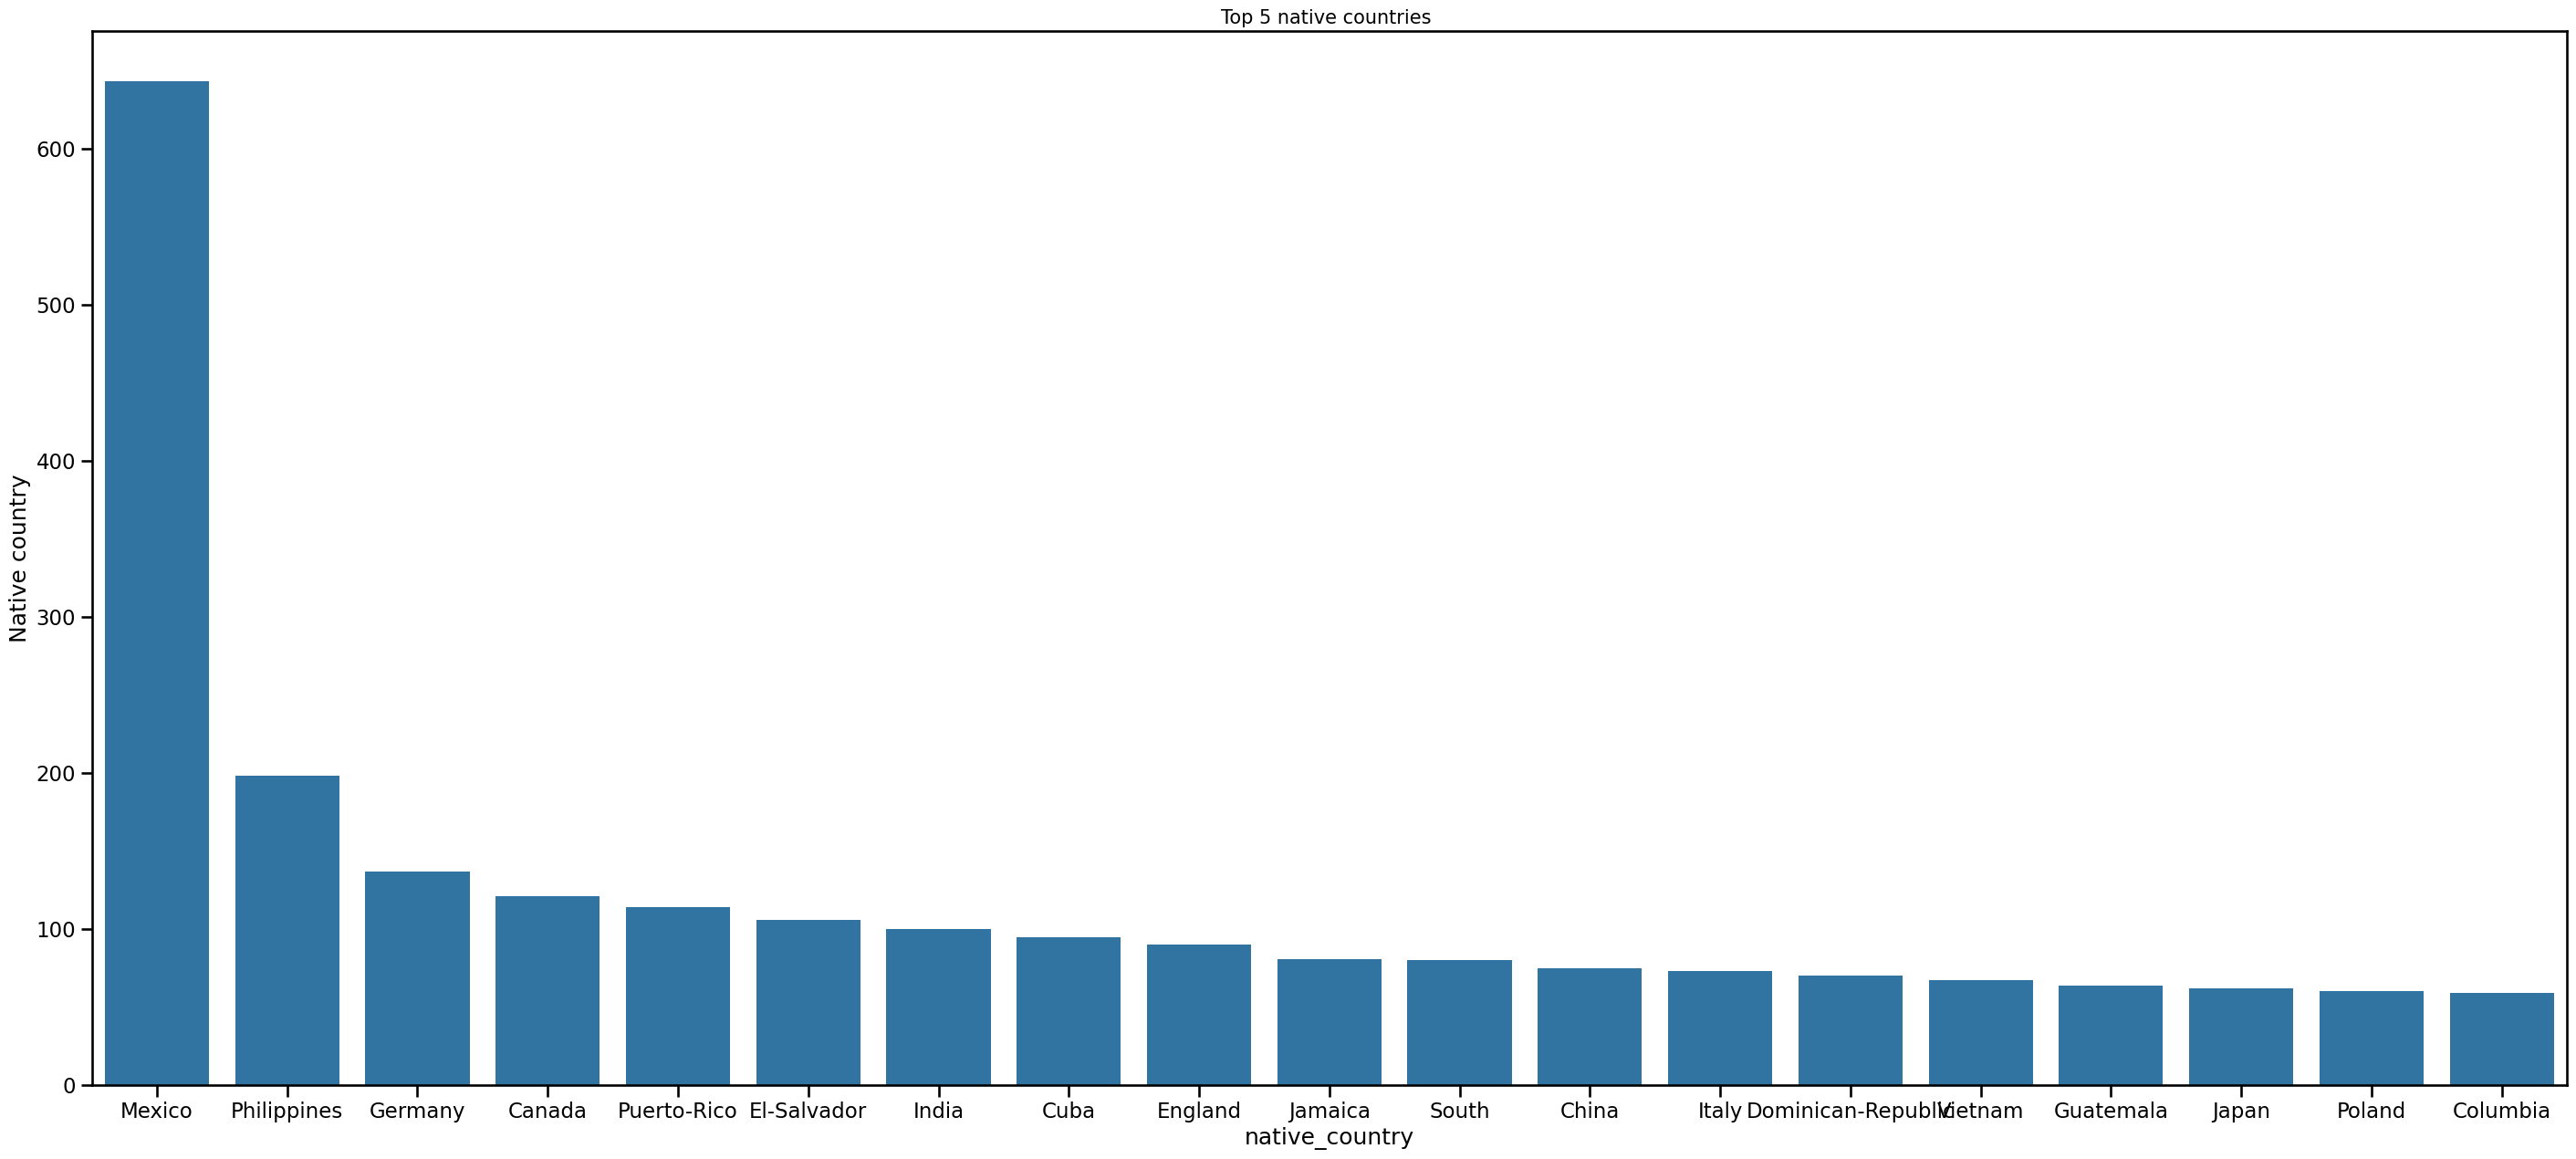

In [ ]:

fig, ax = plt.subplots(figsize=(35, 15))
c = df_train['native_country'].value_counts()[1:20]
ax = sns.barplot(x = c.index, y = c)
ax.set_title('Top 5 native countries ', fontsize=15)
plt.ylabel('Native country');

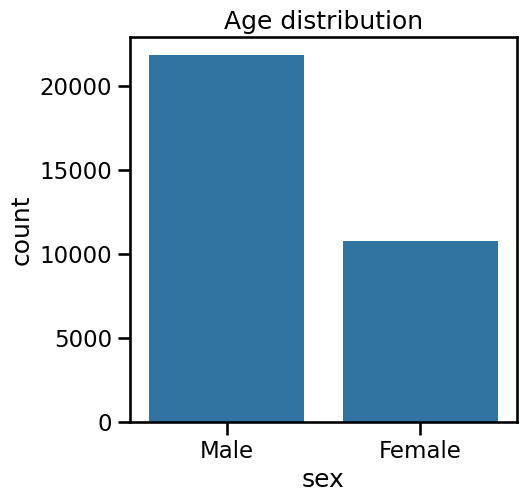

In [ ]:

fig, ax = plt.subplots(figsize=(5,5))
s = df_train.sex.value_counts()
ax = sns.barplot(x = s.index, y = s )
plt.title('Age distribution');

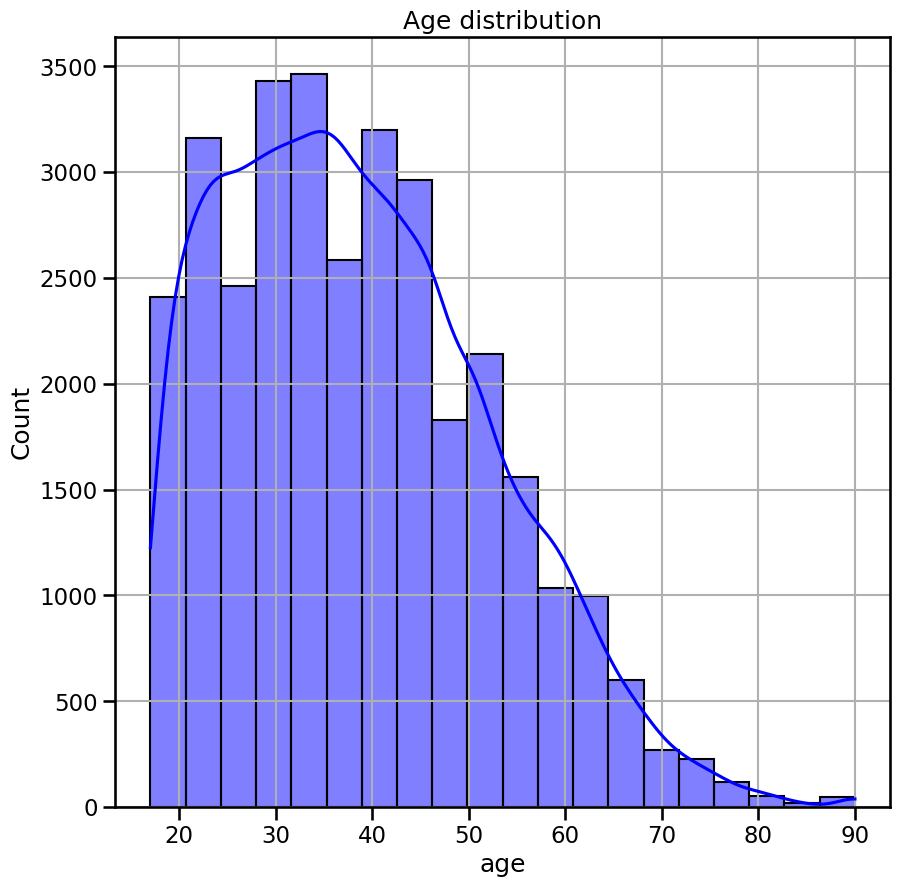

In [ ]:

fig, ax = plt.subplots(figsize=(10,10))
ax = sns.histplot(df_train.age, bins=20, kde=True, color='blue')
plt.title('Age distribution')
plt.grid(True);

In [16]:

def detect_remove_plot_outliers(df, column):
    """
    Detect, remove, and visualize outliers in a numerical feature using the 3-sigma rule.

    Args:
        df (pd.DataFrame): DataFrame containing the data.
        column (str): Name of the numerical column to check for outliers.

    Returns:
        df_cleaned (pd.DataFrame): DataFrame after removing rows with outliers in the specified column.
    """
    # Calculate statistics
    mean = df[column].mean()
    std = df[column].std()
    threshold = 3 * std
    lower, upper = mean - threshold, mean + threshold

    # Identify outliers
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    num_outliers = len(outliers)
    total = len(df)

    # Print summary
    print(f"Feature: {column}")
    print(f"Mean: {mean:.2f}, Std: {std:.2f}")
    print(f"Lower threshold: {lower:.2f}, Upper threshold: {upper:.2f}")
    print(f"Total observations: {total}")
    print(f"Number of outliers: {num_outliers} ({(num_outliers/total)*100:.2f}%)")

    # Plot before and after
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.boxplot(x=df[column], ax=axes[0], color='skyblue')
    axes[0].set_title(f"{column} - Before Outlier Removal")

    df_cleaned = df[(df[column] >= lower) & (df[column] <= upper)]

    sns.boxplot(x=df_cleaned[column], ax=axes[1], color='salmon')
    axes[1].set_title(f"{column} - After Outlier Removal")

    plt.tight_layout()
    plt.show()

    return df_cleaned


Feature: age
Mean: 38.58, Std: 13.64
Lower threshold: -2.34, Upper threshold: 79.50
Total observations: 32561
Number of outliers: 121 (0.37%)


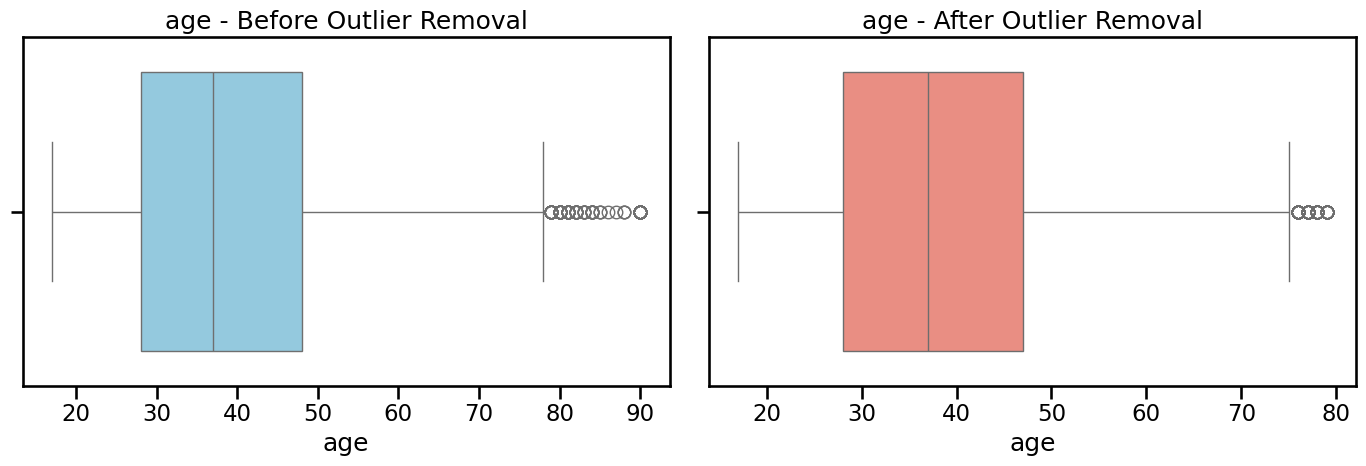

Feature: fnlwgt
Mean: 189880.70, Std: 105586.27
Lower threshold: -126878.11, Upper threshold: 506639.51
Total observations: 32440
Number of outliers: 345 (1.06%)


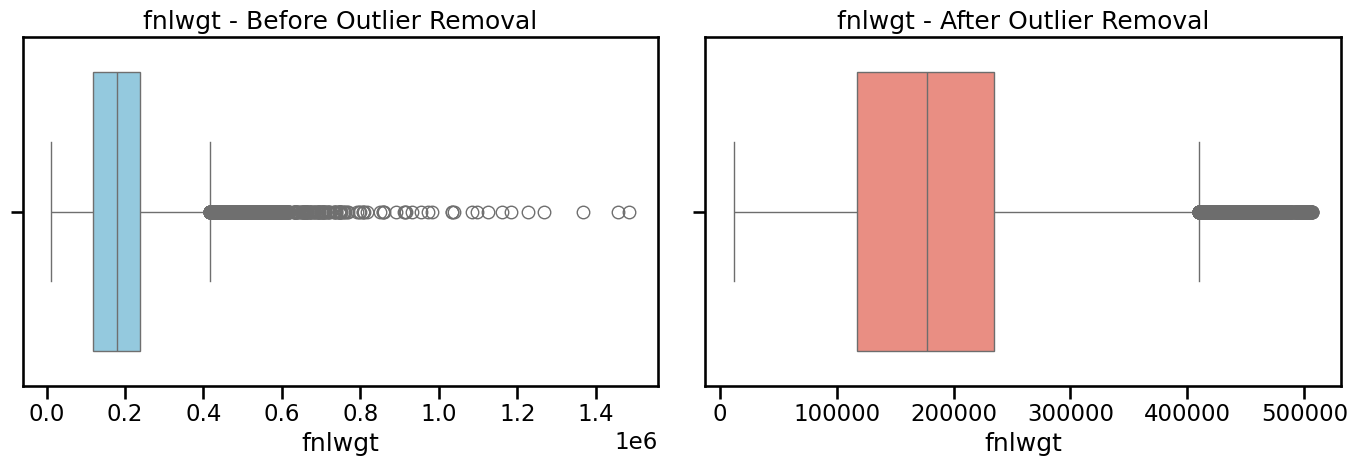

Feature: education_num
Mean: 10.09, Std: 2.57
Lower threshold: 2.39, Upper threshold: 17.79
Total observations: 32095
Number of outliers: 209 (0.65%)


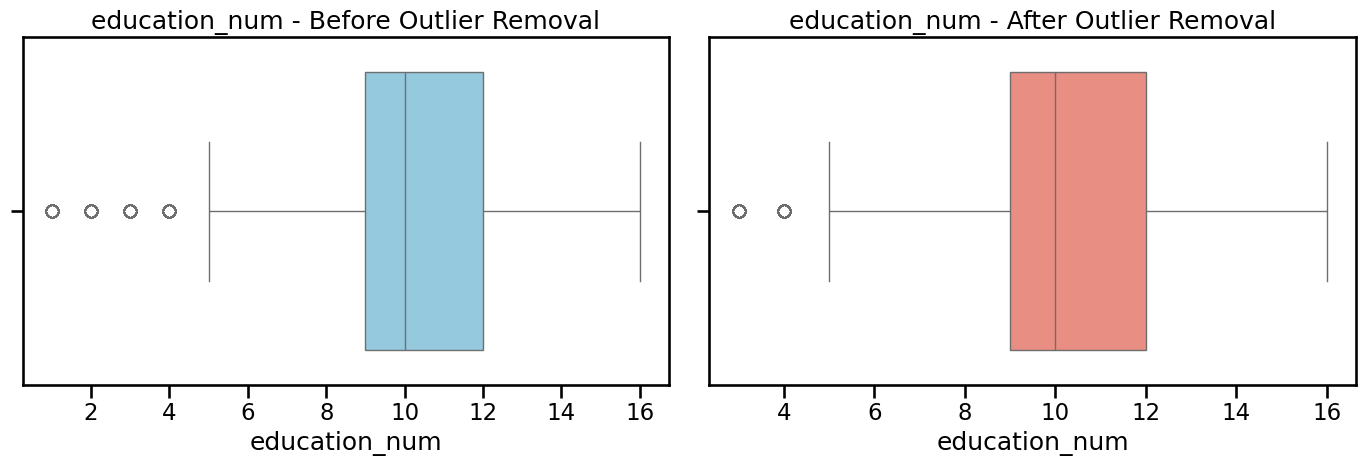

Feature: capital_gain
Mean: 1084.68, Std: 7429.91
Lower threshold: -21205.03, Upper threshold: 23374.40
Total observations: 31886
Number of outliers: 212 (0.66%)


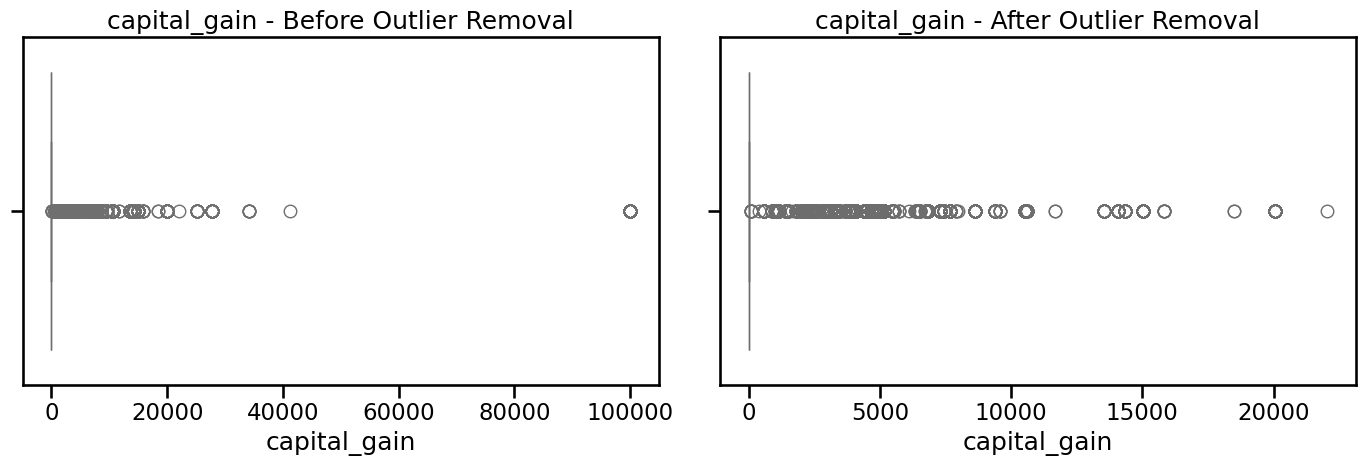

Feature: capital_loss
Mean: 88.26, Std: 404.23
Lower threshold: -1124.42, Upper threshold: 1300.94
Total observations: 31674
Number of outliers: 1448 (4.57%)


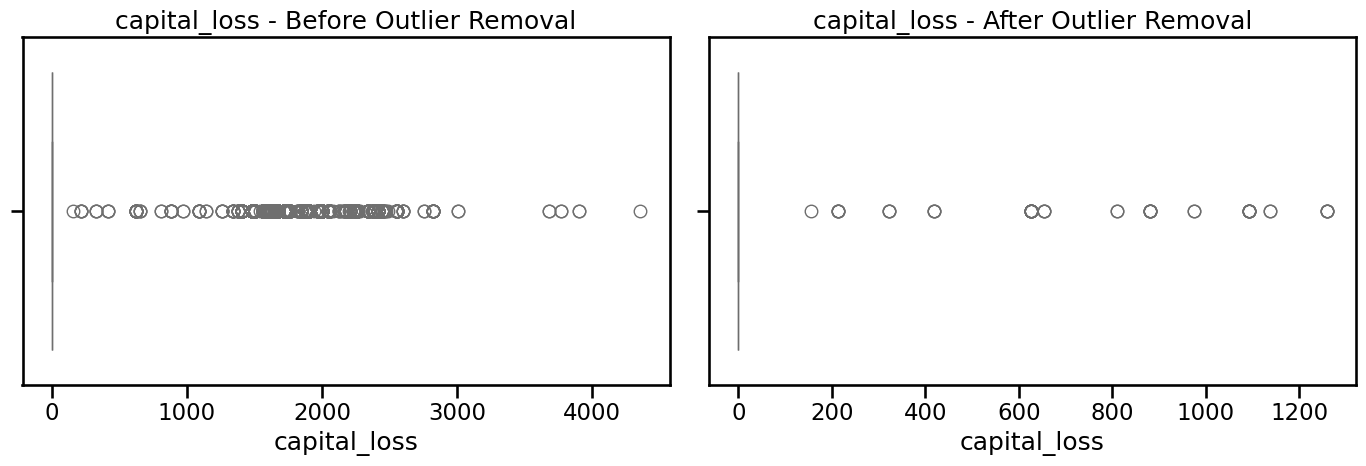

Feature: hours_per_week
Mean: 40.30, Std: 12.27
Lower threshold: 3.50, Upper threshold: 77.10
Total observations: 30226
Number of outliers: 397 (1.31%)


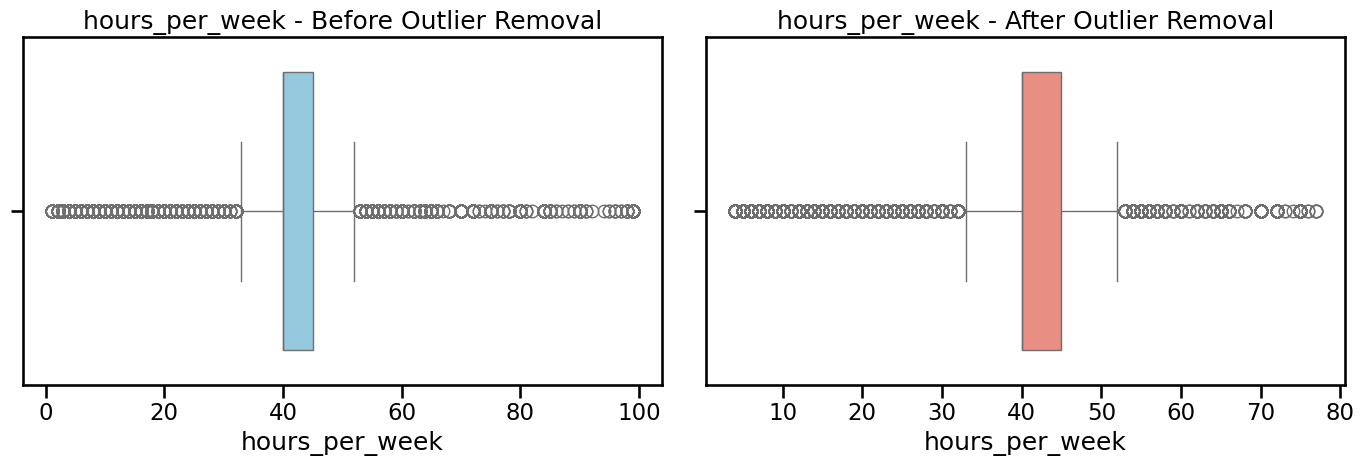

In [17]:
for col in df_train.select_dtypes(include=np.number).columns:
    df_train = detect_remove_plot_outliers(df_train, col)


### preprocessing

In [18]:
def missing_col(df):
    missing_columns = df.columns[df.isnull().any()].tolist()
    if missing_columns:
        print(f"Columns with missing values: {missing_columns}")
        return missing_columns
    else:
        print("No columns with missing values.")
        
missing_columns_train = missing_col(df_train)
missing_columns_test = missing_col(df_test)        

Columns with missing values: ['workclass', 'occupation', 'native_country']
Columns with missing values: ['workclass', 'occupation', 'native_country']


In [19]:
def fill_missing_values(df, missing_cols):
    for col in missing_cols:
        if df[col].dtype == 'object':
            df[col].fillna(df[col].mode()[0], inplace=True)  # Fill categorical with mode
        else:
            df[col].fillna(df[col].median(), inplace=True)  # Fill numerical with mean
    return df

df_train = fill_missing_values(df_train, missing_columns_train)
df_test = fill_missing_values(df_test, missing_columns_test)

In [20]:
df_train.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [21]:
df_train.duplicated().sum()

20

In [22]:
df_test.duplicated().sum()

5

In [23]:
df_train.drop_duplicates(inplace=True)
df_test.drop_duplicates(inplace=True)

In [24]:
def calculate_unique_values(df):
    unique_counts = {}
    for col in df.columns:
        unique_counts[col] = df[col].nunique()
    return unique_counts
unique_train = calculate_unique_values(df_train)
unique_test = calculate_unique_values(df_test)

In [25]:
unique_train

{'age': 63,
 'workclass': 8,
 'fnlwgt': 20238,
 'education': 14,
 'education_num': 14,
 'marital_status': 7,
 'occupation': 14,
 'relationship': 6,
 'race': 5,
 'sex': 2,
 'capital_gain': 111,
 'capital_loss': 13,
 'hours_per_week': 72,
 'native_country': 40,
 'income': 2}

In [26]:
def check_skewness(df):
    skewness = df.select_dtypes(include=[np.number]).apply(lambda x: x.skew()).sort_values(ascending=False)
    print("Skewness of numerical features:")
    print(skewness)
    return skewness
skewness_train = check_skewness(df_train)


Skewness of numerical features:
capital_loss      29.652261
capital_gain       4.941799
fnlwgt             0.635195
age                0.491127
education_num     -0.169865
hours_per_week    -0.353131
dtype: float64


In [27]:
for col in ['capital_loss', 'capital_gain']:
    df_train[col] = np.log1p(df_train[col])
    df_test[col] = np.log1p(df_test[col])


In [28]:
df_train.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'sex',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
       'income'],
      dtype='object')

In [29]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

# # Your categorical columns list
# ohe_columns = ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex']
# le_columns = ['native_country', 'income']

# # One-Hot Encoding: Fit on train, apply to both train and test
# ohe = OneHotEncoder(handle_unknown='ignore', sparse=False) # regular 2D NumPy array, you set sparse=False.
# ohe.fit(df_train[ohe_columns])

# # Transform train and test
# df_train_ohe = pd.DataFrame(ohe.transform(df_train[ohe_columns]), 
#                             columns=ohe.get_feature_names_out(ohe_columns), index=df_train.index)
# df_test_ohe = pd.DataFrame(ohe.transform(df_test[ohe_columns]), 
#                            columns=ohe.get_feature_names_out(ohe_columns), index=df_test.index)

# # Drop original ohe columns and concatenate
# df_train = df_train.drop(columns=ohe_columns).join(df_train_ohe)
# df_test = df_test.drop(columns=ohe_columns).join(df_test_ohe)




In [30]:
# clean test income column as there is a period in the test data but not in the train data
df_test['income'] = df_test['income'].str.strip().str.replace('.', '', regex=False)

le_columns = ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex','native_country', 'income']

encoders = {}

for col in le_columns:
    le = LabelEncoder()
    df_train[col] = le.fit_transform(df_train[col])
    
    # Create mapping
    le_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    
    # Map test values, unknowns become -1
    df_test[col] = df_test[col].map(le_mapping).fillna(-1).astype(int)
    
    encoders[col] = le_mapping  # Save mapping for reference

In [31]:
print(df_train['income'].value_counts())


income
0    23157
1     6652
Name: count, dtype: int64


In [32]:
print(df_test['income'].value_counts())

income
0    12429
1     3846
Name: count, dtype: int64


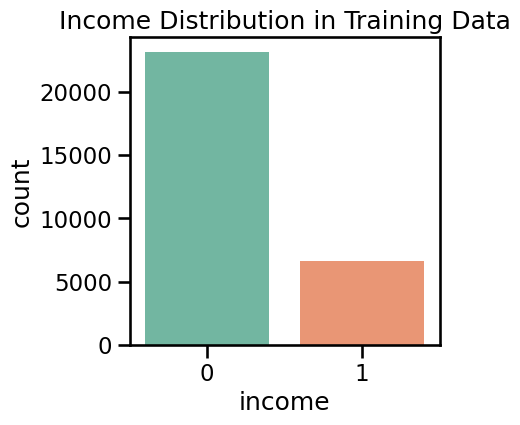

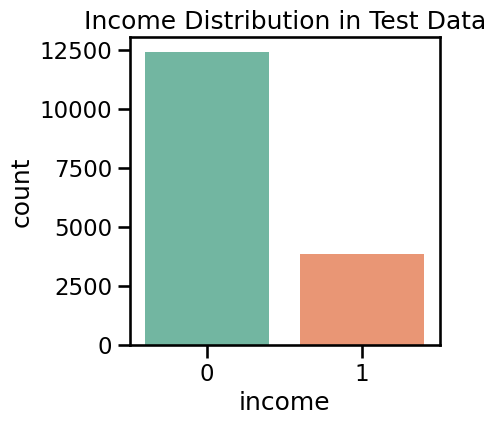

In [33]:
import warnings
warnings.filterwarnings("ignore")
def plot_income_distribution(df, title):
    fig , ax = plt.subplots(figsize=(4, 4))
    sns.countplot(x='income', data=df, ax=ax, palette='Set2')
    ax.set_title(title)
    plt.show()
    
plot_income_distribution(df_train, 'Income Distribution in Training Data')
plot_income_distribution(df_test, 'Income Distribution in Test Data')

In [34]:
# df_viz = df_train.copy()

# df_viz['sex'] = np.where(df_viz['sex_Female'] == 1, 'Female', 'Male')
# df_viz['income_label'] = df_viz['income'].map({0: '<=50K', 1: '>50K'})

# income_sex = pd.crosstab(df_viz['income_label'], df_viz['sex'])

# # Plot as before
# income_sex.plot(kind='bar', figsize=(8, 6), color=['salmon', 'skyblue'])
# plt.legend(title='Sex')
# plt.xlabel('Income Category')
# plt.ylabel('Count')
# plt.title('Income vs. Sex Distribution')
# plt.xticks(rotation=0)
# plt.yticks(np.arange(0, income_sex.values.max() + 2000, 2000))

# plt.show()


In [35]:
print(df_train.head(2))

   age  workclass  fnlwgt  education  education_num  marital_status  \
0   39          6   77516          8             13               4   
1   50          5   83311          8             13               2   

   occupation  relationship  race  sex  capital_gain  capital_loss  \
0           0             1     4    1      7.684784           0.0   
1           3             0     4    1      0.000000           0.0   

   hours_per_week  native_country  income  
0              40              37       0  
1              13              37       0  


### Modelling

In [61]:
X_train = df_train.drop('income' , axis=1)
y_train = df_train['income']

X_test = df_test.drop('income', axis=1)
y_test = df_test['income']

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((29809, 14), (29809,), (16275, 14), (16275,))

In [62]:
from sklearn.preprocessing import StandardScaler

# List of numeric columns to scale
numeric_features = ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']

# Initialize the scaler
scaler = StandardScaler()

# Fit-transform on training data, transform on test data
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

# Verify scaling
print(X_train_scaled.head(2))


        age  workclass    fnlwgt  education  education_num  marital_status  \
0  0.063816          6 -1.138820          8       1.191178               4   
1  0.887316          5 -1.077535          8       1.191178               2   

   occupation  relationship  race  sex  capital_gain  capital_loss  \
0           0             1     4    1      2.959796     -0.040022   
1           3             0     4    1     -0.295621     -0.040022   

   hours_per_week  native_country  
0        0.009070              37  
1       -2.415276              37  


In [ ]:
from imblearn.over_sampling import SMOTE

# smote = SMOTE(random_state=42, sampling_strategy=0.5)  # Adjust sampling_strategy as needed
# X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

from imblearn.over_sampling import ADASYN  # Adaptive Synthetic Sampling as an alternative to SMOTE 
ada = ADASYN(random_state=42)  # because it can handle imbalanced datasets more effectively by generating synthetic samples for the minority class.



X_train_balanced, y_train_balanced = ada.fit_resample(X_train_scaled, y_train)

print("Original dataset shape:", X_train_scaled.shape, y_train.shape)
print("Balanced dataset shape:", X_train_balanced.shape, y_train_balanced.shape)

Original dataset shape: (29809, 14) (29809,)
Balanced dataset shape: (44838, 14) (44838,)


[LightGBM] [Info] Number of positive: 21681, number of negative: 23157
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003631 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1382
[LightGBM] [Info] Number of data points in the train set: 44838, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.483541 -> initscore=-0.065861
[LightGBM] [Info] Start training from score -0.065861


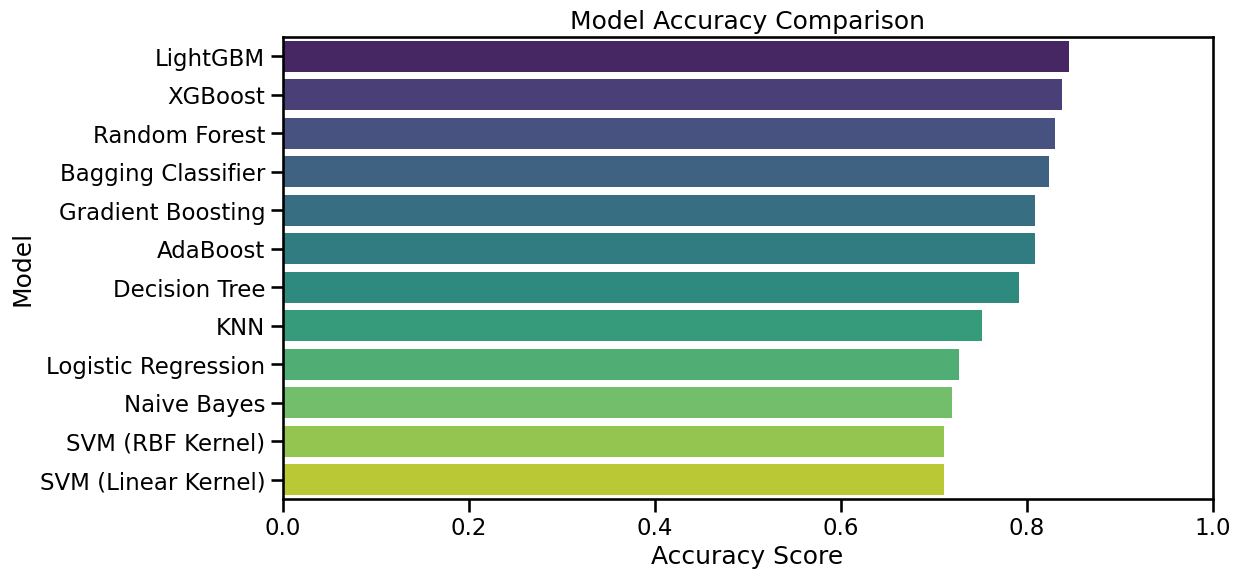

,Model,Accuracy
0,LightGBM,0.845837
1,XGBoost,0.838402
2,Random Forest,0.830476
3,Bagging Classifier,0.824455
4,Gradient Boosting,0.809217
5,AdaBoost,0.808909
6,Decision Tree,0.792381
7,KNN,0.751889
8,Logistic Regression,0.727803
9,Naive Bayes,0.720307


In [64]:
# Import required libraries
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score

# from imblearn.ensemble import EasyEnsembleClassifier
# eec = EasyEnsembleClassifier(random_state=42)
# eec.fit(X_train, y_train)

# Define models dictionary
models = {
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM (RBF Kernel)': SVC(kernel='rbf', random_state=42),
    'SVM (Linear Kernel)': SVC(kernel='linear', random_state=42),
    'Naive Bayes': GaussianNB(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'Bagging Classifier': BaggingClassifier(random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    'LightGBM': LGBMClassifier(random_state=42)
}

# Function to fit models and return accuracy scores
def fit_and_score(models, X_train, X_test, y_train, y_test):
    """
    Fits and evaluates models, returns accuracy scores.
    """
    model_scores = {}
    
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        model_scores[name] = acc
        
    return model_scores

# Run model fitting
# Fit and evaluate models using scaled data
scores = fit_and_score(models, X_train_balanced, X_test_scaled, y_train_balanced, y_test)



# Convert scores to DataFrame for plotting
scores_df = pd.DataFrame(list(scores.items()), columns=['Model', 'Accuracy']).sort_values(by='Accuracy', ascending=False)

# Plot the scores
plt.figure(figsize=(12,6))
sns.barplot(x='Accuracy', y='Model', data=scores_df, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.xlabel('Accuracy Score')
plt.xlim(0,1)
plt.show()

# Show scores
scores_df.reset_index(drop=True)


🔍 Evaluation on  Train Set:

--- Train Metrics ---
Accuracy: 0.8748
F1 Score: 0.8839
Precision: 0.8010
Recall: 0.9860
ROC-AUC: 0.8783

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.77      0.86     23157
           1       0.80      0.99      0.88     21681

    accuracy                           0.87     44838
   macro avg       0.89      0.88      0.87     44838
weighted avg       0.90      0.87      0.87     44838



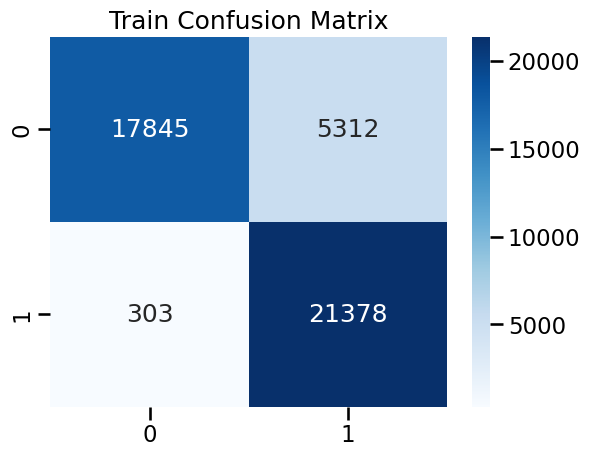


🔍 Evaluation on Original Test Set:

--- Test Metrics ---
Accuracy: 0.7790
F1 Score: 0.6490
Precision: 0.5194
Recall: 0.8648
ROC-AUC: 0.8086

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.75      0.84     12429
           1       0.52      0.86      0.65      3846

    accuracy                           0.78     16275
   macro avg       0.73      0.81      0.74     16275
weighted avg       0.85      0.78      0.79     16275



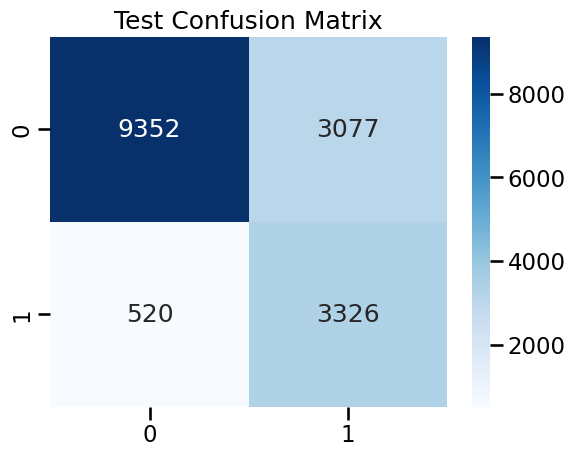

In [66]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, classification_report, confusion_matrix
from xgboost import XGBClassifier


scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
xgb = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42,eval_metric='logloss')


xgb.fit(X_train_balanced, y_train_balanced)

# Predict on training (SMOTE data) and test (unseen data)
y_train_pred = xgb.predict(X_train_balanced)
y_test_pred = xgb.predict(X_test_scaled)

# # Evaluation function
def evaluate_model(y_true, y_pred, dataset='Test'):
    print(f"\n--- {dataset} Metrics ---")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall: {recall_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC: {roc_auc_score(y_true, y_pred):.4f}")
    print("\nClassification Report:\n", classification_report(y_true, y_pred))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{dataset} Confusion Matrix')
    plt.show()

# Evaluate on both sets
print("🔍 Evaluation on  Train Set:")
evaluate_model(y_train_balanced , y_train_pred, dataset='Train')

print("\n🔍 Evaluation on Original Test Set:")
evaluate_model(y_test, y_test_pred, dataset='Test')


In [67]:
from sklearn.model_selection import RandomizedSearchCV
xgb_grid = {'min_child_weight': np.arange(1,10,2),
           'max_depth': np.arange(3,13,3),
            'learning_rate': [0.1, 0.5, 0.3],
            'gamma': [0, 0.1, 0.2],
            'n_estimators': [1000, 1200],
            'subsample': [0.5, 1],
            'colsample_bytree': [0.5, 1]}
np.random.seed(42)

rs_xgb = RandomizedSearchCV(XGBClassifier(),
                           param_distributions=xgb_grid,
                           cv=3,
                           verbose=True,
                           n_jobs=-1)

rs_xgb.fit(X_train_scaled, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           gamma=None, grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learning_rate...
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None,
                                           random_state=None, ...),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.5, 1],
                                        'gamma': [0, 0.1, 0.2],
                                        'learning_rate': [0.1, 0.5, 0.3],
                                        'max_depth': array([ 3,  6,  9, 12]),
                                        'min_child_weight': array([1, 3, 5, 7, 9]),
                                        'n_estimators': [1000, 1200],
                                        'subsample': [0.5, 1]},
                   verbose=True)

In [68]:
rs_xgb.best_params_

{'subsample': 0.5,
 'n_estimators': 1200,
 'min_child_weight': 5,
 'max_depth': 3,
 'learning_rate': 0.3,
 'gamma': 0.1,
 'colsample_bytree': 1}

In [69]:
rs_xgb.best_score_

0.8525613336645667

In [70]:
rs_xgb.score(X_train_scaled, y_train)

0.8995269884934081

In [71]:
rs_xgb.score(X_test_scaled, y_test)

0.8522273425499232


--- Test Metrics ---
Accuracy: 0.8522
F1 Score: 0.6614
Precision: 0.7212
Recall: 0.6108
ROC-AUC: 0.7689

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.93      0.91     12429
           1       0.72      0.61      0.66      3846

    accuracy                           0.85     16275
   macro avg       0.80      0.77      0.78     16275
weighted avg       0.85      0.85      0.85     16275



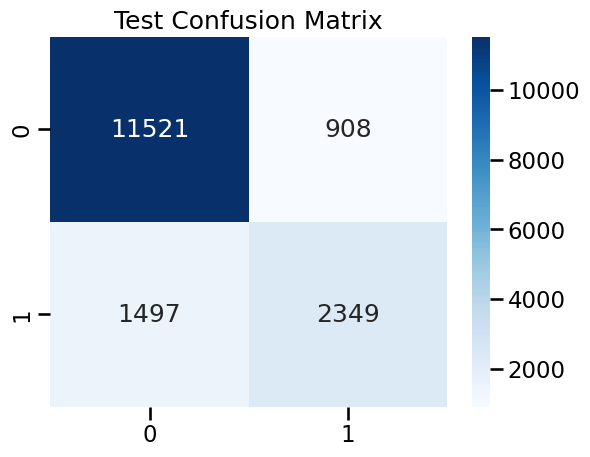

In [72]:
best_xgb = rs_xgb.best_estimator_

# Predict on test
y_test_pred = best_xgb.predict(X_test_scaled)
evaluate_model(y_test, y_test_pred, dataset='Test')


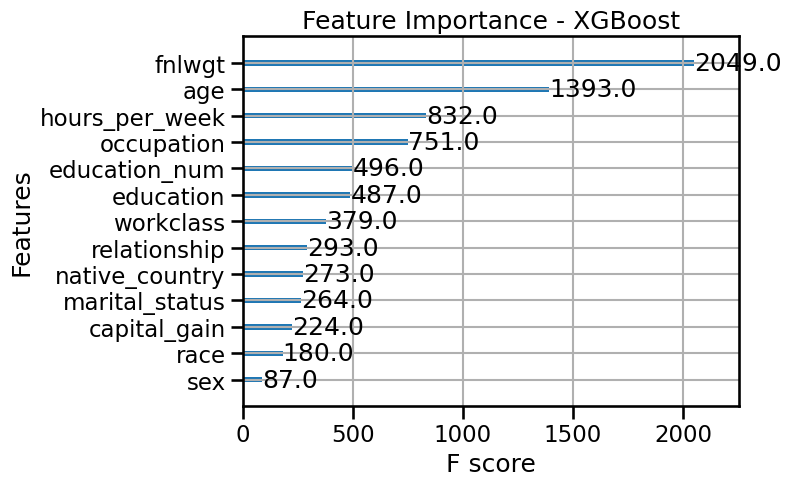

In [73]:
from xgboost import plot_importance
plot_importance(best_xgb, max_num_features=15, importance_type='weight', title='Feature Importance - XGBoost')
plt.show()
